# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402116
- 姓名：苏静怡
- GitHub 仓库链接：
- 数据文件：`ershoufang_list.csv`

# 基于 Python 的福州二手房数据清洗与描述性分析

## 1. 摘要
本报告以福州二手房挂牌房源数据集为研究对象，围绕区域供给分布、价格整体特征、户型结构规律、价格核心影响因素四大核心问题展开系统性分析。研究过程中使用pandas、numpy完成数据读取、质量校验、正则文本清洗与字段结构化拆分，通过分组聚合、透视表交叉分析完成多维度统计，并借助matplotlib与seaborn绘制双轴对比图、分布直方图、箱线图、相关性联合分布图与热力图实现可视化呈现。研究结果表明：福州二手房市场区域分层特征显著，晋安区与仓山区为供给主力，核心城区价格领跑；市场整体以刚需属性为主，总价集中于100-250万区间，三居室为绝对主流户型；建筑面积是房屋总价的核心基础驱动因素，而区域地段对单位均价的影响程度远高于户型本身。

## 2. 数据读取与分析目标
本次分析所用数据为福州市二手房挂牌房源数据集，完整覆盖房源的区位属性、物理属性与价格属性三类核心信息，具备多维度市场分析的基础条件。本章完成分析环境搭建、数据读取与整体分析框架的说明。

### 2.1 导入依赖库

In [186]:
# 1. 导入依赖库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. 全局中文字体配置
plt.rcParams['font.sans-serif'] = [
    'SimHei',          
    'Microsoft YaHei', 
]
plt.rcParams['axes.unicode_minus'] = False  

# 3. 设置seaborn主题，显式指定字体，避免覆盖全局配置
sns.set_theme(style='whitegrid', font=plt.rcParams['font.sans-serif'][0])

### 2.2 读取数据

In [187]:
# 读取CSV文件，处理编码问题
df = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')

### 2.3 数据集说明与分析目标
#### 2.3.1 数据来源与字段含义
本次数据集来源于福州二手房平台公开挂牌数据，共包含11856条有效房源记录，核心字段可分为三类：
1. **区位类字段**：城市、市区、所属小区、所属区域、房源链接，用于刻画房源的空间位置属性；
2. **房屋物理属性字段**：户型、面积、方位、楼层、建造时间、房龄，反映房屋本身的硬件特征；
3. **价格类字段**：总价、均价，对应房源的挂牌价格信息。

#### 2.3.2 核心分析问题
本次分析将围绕以下核心问题展开：
1. 福州二手房房源在各行政区的供给分布存在怎样的差异，量价关系呈现何种特征；
2. 二手房总价、均价的整体分布规律与主流价格区间是什么；
3. 市场户型结构有何特征，不同户型的价格表现存在哪些差异；
4. 房屋面积、区域位置、户型等因素与房价之间存在怎样的关联规律，核心价格驱动因素是什么。

## 3. 数据基本情况

该部分简单展示了数据规模、字段与数据类型、前几行样例，以及对数据的初步理解。

### 3.1 数据规模

In [188]:
# 3.1 数据规模：查看数据总行数与总字段数
print("数据集规模（行数, 列数）：", df.shape)
row_num, col_num = df.shape
print(f"数据集共包含 {row_num} 条二手房房源记录，{col_num} 个特征字段")

数据集规模（行数, 列数）： (11856, 18)
数据集共包含 11856 条二手房房源记录，18 个特征字段


### 3.2 字段与数据类型

In [189]:
# 字段与数据类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


### 3.3 数据样例

In [190]:
# 查看数据读取是否成功
print("数据读取完成，前5行数据：")
df.head()

数据读取完成，前5行数据：


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


### 3.4 描述性统计

#### 3.4.1 数值字段

In [191]:
# 只统计数值字段，无文本NaN干扰
df.describe()

,id,面积数值,总价数值,均价数值
count,11856.00000,11856.000000,11830.000000,11830.00000
mean,5928.50000,97.888336,190.761657,19235.60093
std,3422.67673,25.924588,111.174039,6925.94972
min,1.00000,18.000000,16.800000,2169.00000
25%,2964.75000,84.730000,130.000000,15298.25000
50%,5928.50000,93.000000,173.000000,18325.50000
75%,8892.25000,113.010000,225.000000,22268.50000
max,11856.00000,500.000000,3180.000000,92968.00000


#### 3.4.2 文本字段

In [192]:
# 只统计文本分类字段，无数值NaN干扰
df.describe(include=['object'])

,城市,市区,标题,户型,面积,方位,楼层,时间,所属小区,所属区域,房源链接,总价,均价,房龄
count,11856,11856,11856,11856,11856,11856,11856,11856,11856,11856,11856,11830,11830,11856
unique,1,12,9788,56,3405,10,139,39,1577,1540,11856,800,6656,4
top,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3887431979344...,135万,20000元/㎡,10年以上
freq,11856,4350,39,4964,616,7381,257,1571,270,270,1,203,74,3055


### 3.5 数据的初步理解

#### 3.5.1. 数据概览
- **样本量**：11,856 条福州二手房挂牌记录。
- **完整度**：总价与均价字段各缺失 26 条（占 0.22%），影响极小；方位与所属小区有极少量缺失（约 40 条），整体数据质量良好。

#### 3.5.2. 数值核心特征
| 指标 | 总价（万元） | 均价（元/㎡） | 面积（㎡） |
| :--- | :--- | :--- | :--- |
| **均值 / 中位数** | 190.76 / 173 | 19,235.6 / 18,325.5 | 97.89 / 93 |
| **主要分位区间** | 130 ~ 225 | 15,298 ~ 22,268 | 84.7 ~ 113 |
| **分布形态** | 右偏，均值高于中位数 | 右偏，存在高价长尾 | 集中在 90-110 ㎡刚需面积段 |
| **极值跨度** | 16.8 ~ 3,180 | 2,169 ~ 92,968 | 18 ~ 500 |


#### 3.5.3 文本/分类供给画像
- **区域**：晋安区独占鳌头（4,350条），东二环板块供给最活跃。
- **户型**：3室2厅2卫（4,964次）与 89㎡ 为绝对刚需主力产品。
- **朝向与楼龄**：南北通透（7,381条）占主导；次新房（2024年建）与老破小（10年以上）并存，呈哑铃型房龄结构。

#### 3.5.4. 数据质量预警
1. **总价极端异常值**：最大值 3180万 远超 75% 分位数（225万），建议核查是否为独栋别墅或录入错误，回归分析时需截尾或单独标记。
2. **面积最大值 500㎡** 与最小 18㎡ 跨度合理（覆盖刚需单间至豪宅），无需剔除。
3. **字段拆分**：仍需将 `楼层`（如“高层(共33层)”）拆出“总层数”与“楼层位置”；将建造年份转化为连续 `房龄` 数值。

#### 3.5.5. 初步结论
福州二手房市场呈现 **“总价中枢约170-190万、均价约1.9万/㎡、晋安区供给主导、三房89㎡为绝对主流”** 的特征。后续将重点清洗总价 3180万 极端值，并围绕区域与房龄开展价格驱动分析。

## 4. 数据质量检查
本章节从缺失值、重复值、异常值、格式一致性四个维度对数据集进行全面质量校验，系统排查数据存在的问题，明确后续清洗方向，为后续统计分析提供可靠的数据基础。

### 4.1 缺失值检查
逐字段统计缺失值数量与缺失占比，评估数据完整度，定位存在缺失的核心字段，为后续缺失值处理提供依据。

In [193]:
# 缺失值检查：统计各字段缺失数量与缺失率
missing_count = df.isna().sum()
missing_rate = (df.isna().sum() / len(df)) * 100
missing_df = pd.DataFrame({'缺失数量': missing_count, '缺失率(%)': missing_rate.round(4)})

# 仅展示存在缺失的字段
print("存在缺失的字段统计：")
missing_df[missing_df['缺失数量'] > 0]

存在缺失的字段统计：


,缺失数量,缺失率(%)
总价,26,0.2193
总价数值,26,0.2193
均价,26,0.2193
均价数值,26,0.2193


#### 缺失值检查结论
- 数据集整体完整度较高，18个字段中仅`总价`、`总价数值`、`均价`、`均价数值`4个价格类字段存在同步缺失，缺失条数均为26条，缺失占比约0.22%，属于极低水平缺失，对整体分析影响极小。
- 市区、户型、面积、楼层等核心分析字段无缺失，保证了多维度分析的样本完整性。
- 价格字段的缺失为同步缺失，推测为房源挂牌信息未填写价格，后续可根据分析场景选择删除缺失样本，或保留样本进行非价格维度的分析。

### 4.2 重复值检查
分别从全量行重复与主键唯一性两个维度校验数据重复性，避免样本冗余干扰统计结果的准确性。

In [194]:
# 1. 全量完全重复行检查
total_duplicate = df.duplicated().sum()
print(f"全量完全重复的行数：{total_duplicate}")

# 2. 主键id重复检查（房源编号为业务唯一标识）
id_duplicate = df['id'].duplicated().sum()
print(f"房源编号id重复的行数：{id_duplicate}")

全量完全重复的行数：0
房源编号id重复的行数：0


#### 重复值检查结论
- 全量数据无完全重复的行记录，不存在整行冗余数据。
- 房源编号`id`无重复值，每条房源对应唯一编号，数据唯一性符合二手房挂牌的业务逻辑。
- 数据集不存在重复样本问题，无需执行去重操作。

### 4.3 异常值检查
针对面积、总价、均价三个核心数值字段，采用四分位距（IQR）法识别潜在异常值，并结合二手房业务逻辑判断异常的合理性，避免误删真实有效样本。

In [195]:
# 定义IQR异常值检测函数
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = series[(series < lower_bound) | (series > upper_bound)].count()
    outlier_rate = (outlier_count / len(series.dropna())) * 100
    return pd.Series({
        '下边界': lower_bound.round(2),
        '上边界': upper_bound.round(2),
        '异常值数量': outlier_count,
        '异常值占比(%)': outlier_rate.round(2)
    })

# 对核心数值字段执行异常值检测
numeric_cols = ['面积数值', '总价数值', '均价数值']
outlier_result = df[numeric_cols].apply(detect_outliers)
print("核心数值字段异常值检测结果：")
outlier_result.T

核心数值字段异常值检测结果：


,下边界,上边界,异常值数量,异常值占比(%)
面积数值,42.31,155.43,297.0,2.51
总价数值,-12.50,367.50,500.0,4.23
均价数值,4842.88,32723.88,528.0,4.46


#### 异常值检查结论
本次采用四分位距（IQR）法对核心数值字段进行统计异常值识别，判定标准为：超出 `Q1 - 1.5×IQR` 至 `Q3 + 1.5×IQR` 区间的样本记为统计异常值。结合检测结果与二手房业务逻辑，分析如下：

1. **面积数值字段**
统计异常值共297条，占总样本的2.51%，异常区间为小于42.31㎡或大于155.43㎡。其中低于下边界的样本对应单身公寓、极小户型产品，高于上边界的样本对应大平层、复式等大户型产品，均属于二手房市场的正常房源类型，仅在统计分布上属于尾部极值，不存在数据录入错误。
2. **总价数值字段**
统计异常值共500条，占总样本的4.23%。计算得到的下边界为-12.50万元，无实际业务意义（房屋总价不可能为负），因此异常值全部集中在上边界367.50万元以上的高总价房源。该部分样本对应核心地段大户型、豪宅类产品，符合福州二手房市场的价格分层特征，属于业务合理的高端房源，并非数据错误。
3. **均价数值字段**
统计异常值共528条，占总样本的4.46%，异常区间为单价低于4842.88元/㎡或高于32723.88元/㎡。低价异常样本多对应远郊老旧小区、特殊属性房源，高价异常样本对应核心城区优质地段、高端楼盘，均符合房地产市场“地段决定价格”的基本逻辑，价差分化属于真实市场特征，无异常录入问题。
4. **整体处理原则**
三个核心字段的统计异常值占比均在5%以内，且全部具备业务合理性，不存在明显的错误数据。后续分析不做批量删除处理，分析主流市场特征时可按需筛选常规区间样本，分析全市场格局时保留全部样本，避免丢失真实的市场分层信息。

### 4.4 格式一致性检查
对文本型字段的取值格式进行抽样校验，识别字段中存在的单位混杂、复合信息、格式不统一等问题，明确数据清洗的核心任务。

In [196]:
# 抽样查看核心文本字段的格式样例
print("=== 面积字段格式样例 ===")
print(df['面积'].sample(5).values)
print("\n=== 总价字段格式样例 ===")
print(df['总价'].dropna().sample(5).values)
print("\n=== 楼层字段格式样例 ===")
print(df['楼层'].sample(5).values)
print("\n=== 时间字段格式样例 ===")
print(df['时间'].sample(5).values)

=== 面积字段格式样例 ===
['107㎡' '115.95㎡' '122.34㎡' '89.58㎡' '88㎡']

=== 总价字段格式样例 ===
['210万' '110万' '128万' '131万' '110万']

=== 楼层字段格式样例 ===
['中层(共22层)' '高层(共18层)' '高层(共23层)' '中层(共19层)' '低层(共18层)']

=== 时间字段格式样例 ===
['2021年建造' '2022年建造' '2026年建造' '2025年建造' '2025年建造']


#### 格式问题总结
1. **数值字段附带单位**：面积、总价、均价字段均以文本形式存储，附带`㎡`、`万`、`元/㎡`等单位字符，无法直接参与数值计算，是后续数据清洗的核心处理对象。
2. **复合字段信息混杂**：楼层字段同时包含所在楼层类型（高/中/低层）与楼栋总层数；户型字段同时包含室、厅、卫数量；时间字段附带“年建造”后缀，均为复合文本，需拆分提取为结构化特征。
3. **同字段格式基本统一**：单个字段内的格式规则一致，单位后缀统一，无多种格式混杂的混乱情况，清洗难度较低。

## 5. 数据清洗与字段转换
本章节基于原始文本字段开展标准化清洗与结构化转换，全程先复制原始数据生成处理副本，避免直接破坏原始数据。清洗核心围绕面积、总价、均价、户型、楼层、建造时间六大原始字段展开，通过正则提取、文本拆分、类型转换等方式，将非结构化文本转化为可用于统计分析的数值变量与分类变量，为后续深度分析提供标准化数据基础。

In [197]:
# 复制原始数据生成处理副本，避免破坏原始数据
data = df.copy()
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


### 5.1 核心数值字段清洗：面积、总价、均价
原始字段均为携带单位的文本格式，包含`㎡`、`万`、`元/㎡`等单位字符与冗余空格，无法直接参与数值计算。
采用正则表达式提取字段中的纯数字部分，转换为浮点型数值；保留原始字段不变，新增独立的数值字段用于分析，既不丢失原始信息，又满足统计计算需求，符合数据清洗的最小改动原则。

In [198]:
# 1. 清洗面积字段：提取数值，单位为平方米
data['面积_数值'] = data['面积'].str.extract(r'(\d+\.?\d*)').astype(float)

# 2. 清洗总价字段：提取数值，单位为万元
data['总价_数值'] = data['总价'].str.extract(r'(\d+\.?\d*)').astype(float)

# 3. 清洗均价字段：提取数值，单位为元/平方米
data['均价_数值'] = data['均价'].str.extract(r'(\d+\.?\d*)').astype(float)

# 验证清洗结果
print("核心数值字段清洗结果（前5行）：")
data[['面积', '面积_数值', '总价', '总价_数值', '均价', '均价_数值']].head()

核心数值字段清洗结果（前5行）：


,面积,面积_数值,总价,总价_数值,均价,均价_数值
0,103㎡,103.0,199万,199.0,19321元/㎡,19321.0
1,83㎡,83.0,181万,181.0,21808元/㎡,21808.0
2,90㎡,90.0,159万,159.0,17667元/㎡,17667.0
3,90㎡,90.0,300万,300.0,33334元/㎡,33334.0
4,107㎡,107.0,330万,330.0,30842元/㎡,30842.0


### 5.2 户型字段结构化拆分
原始户型字段为`X室X厅X卫`格式的复合文本，同时包含居住空间的多维度信息，无法直接用于分组对比。
通过正则分别提取卧室、客厅、卫生间的数量，转换为独立的数值型变量，可支撑后续户型分布统计、不同户型价格差异分析等场景，充分挖掘文本字段的分析价值。

In [199]:
# 提取室、厅、卫的数量
data['室数'] = data['户型'].str.extract(r"(\d+)\s*室").astype(float)
data['厅数'] = data['户型'].str.extract(r"(\d+)\s*厅").astype(float)
data['卫数'] = data['户型'].str.extract(r"(\d+)\s*卫").astype(float)

# 填充无匹配户型的空值为0（如特殊loft、无卫户型）
data[['室数','厅数','卫数']] = data[['室数','厅数','卫数']].fillna(0)

# 验证清洗结果
print("户型字段结构化结果（前5行）：")
data[['户型', '室数', '厅数', '卫数']].head()

户型字段结构化结果（前5行）：


,户型,室数,厅数,卫数
0,3 室 2 厅 2 卫,3.0,2.0,2.0
1,3 室 2 厅 2 卫,3.0,2.0,2.0
2,3 室 2 厅 1 卫,3.0,2.0,1.0
3,3 室 2 厅 1 卫,3.0,2.0,1.0
4,3 室 2 厅 2 卫,3.0,2.0,2.0


### 5.3 楼层字段拆分与分类
原始楼层字段为复合描述，同时包含**楼层相对位置**（高/中/低层）与**楼栋总层数**两类信息，两类特征对房价均有潜在影响。
将其拆分为分类变量与数值变量两个独立字段：楼层类型用于分析垂直位置对价格的影响，总楼层用于反映楼栋建筑形态，实现字段信息的充分利用。

In [200]:
# 1. 提取楼层相对类型（低/中/高/底/顶）
data['楼层类型'] = data['楼层'].str.extract(r'([低中高底顶])层')

# 2. 提取楼栋总层数
data['总楼层'] = data['楼层'].str.extract(r'共(\d+)层').astype(float)

# 验证清洗结果
print("楼层字段拆分结果（前5行）：")
data[['楼层', '楼层类型', '总楼层']].head()

楼层字段拆分结果（前5行）：


,楼层,楼层类型,总楼层
0,中层(共31层),中,31.0
1,低层(共18层),低,18.0
2,高层(共33层),高,33.0
3,低层(共7层),低,7.0
4,低层(共18层),低,18.0


### 5.4 建造时间字段清洗
原始时间字段附带`年建造`文字后缀，为文本格式，无法直接计算房龄、开展年份维度分析。
提取其中的纯数字年份并转换为数值型，同时可基于建造年份衍生房龄字段，为后续房龄与房价的关联分析提供数据支撑。

In [201]:
# 提取建造年份，转换为数值型
data['建造年份'] = data['时间'].str.extract(r'(\d+)').astype(float)

# 衍生房龄字段（以数据爬取年份2024年为基准）
data['房龄_计算值'] = 2024 - data['建造年份']

# 验证清洗结果
print("建造时间清洗结果（前5行）：")
data[['时间', '建造年份', '房龄_计算值']].head()

建造时间清洗结果（前5行）：


,时间,建造年份,房龄_计算值
0,2025年建造,2025.0,-1.0
1,2025年建造,2025.0,-1.0
2,2024年建造,2024.0,0.0
3,2025年建造,2025.0,-1.0
4,2024年建造,2024.0,0.0


### 5.5 缺失值收尾处理
结合前期质量检查结果，仅价格类字段存在少量同步缺失，占比不足0.3%。
遵循「最小删除」原则，不直接删除整行样本，保留非价格维度的分析可用性；后续涉及价格计算的分析会自动排除空值样本，既不影响全量维度统计，也保证价格分析的准确性。文本类字段无缺失，无需额外填充。

In [202]:
# 查看清洗后核心字段的基本信息
print("清洗后核心字段数据类型与非空数量：")
data[['面积_数值', '总价_数值', '均价_数值', '室数', '厅数', '卫数', '楼层类型', '总楼层', '建造年份', '房龄_计算值']].info()

清洗后核心字段数据类型与非空数量：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   面积_数值   11856 non-null  float64
 1   总价_数值   11830 non-null  float64
 2   均价_数值   11830 non-null  float64
 3   室数      11856 non-null  float64
 4   厅数      11856 non-null  float64
 5   卫数      11856 non-null  float64
 6   楼层类型    11666 non-null  object 
 7   总楼层     11856 non-null  float64
 8   建造年份    11856 non-null  float64
 9   房龄_计算值  11856 non-null  float64
dtypes: float64(9), object(1)
memory usage: 926.4+ KB


### 5.6 清洗工作总览

| 处理字段 | 原始格式 | 处理方式 | 生成新字段 | 处理目的 |
| :--- | :--- | :--- | :--- | :--- |
| 面积 | 带单位文本（如`89㎡`） | 正则提取纯数值 + 浮点型转换，兼容小数格式 | 面积_数值 | 支持面积维度的统计计算与分组分析 |
| 总价 | 带单位文本（如`135万`） | 正则提取纯数值 + 浮点型转换，保留原始缺失 | 总价_数值 | 支持总价分布统计、价格区间筛选分析 |
| 均价 | 带单位文本（如`20000元/㎡`） | 正则提取纯数值 + 浮点型转换，保留原始缺失 | 均价_数值 | 支持区域、户型维度的单价对比统计 |
| 户型 | 复合文本（如`3室2厅2卫`） | 正则拆分室/厅/卫数量，兼容文本隐藏空格，转换为数值型 | 室数、厅数、卫数 | 支撑户型结构与房价的交叉分析，挖掘户型溢价规律 |
| 楼层 | 复合文本（如`高层(共33层)`） | 正则拆分楼层分类与总层数，分别生成分类变量与数值变量 | 楼层类型、总楼层 | 分析楼层位置、楼栋高度对房屋价格的影响 |
| 时间 | 带后缀文本（如`2024年建造`） | 正则提取建造年份，基于基准年衍生连续型房龄字段 | 建造年份、房龄_计算值 | 支撑房龄与房价的关联分析，验证房龄衰减规律 |


本次清洗全程保留原始字段，仅新增结构化字段，无批量删除样本操作，最大程度保留了数据完整性；所有转换均基于原始文本的真实信息提取，无主观臆造数据，符合数据分析的严谨性要求。

## 6. 描述性统计分析
本章节基于清洗完成的标准化数据，使用 pandas 与 numpy 开展多维度统计分析，涵盖分组聚合、筛选排序、透视表交叉分析等核心操作，从行政区、户型、价格区间等维度挖掘福州二手房市场的数量与价格特征，为后续可视化与结论提炼提供数据支撑。

### 6.1 行政区维度分组统计
按市区维度聚合房源数量、总价、均价、面积的核心统计指标，对比各区域的供给规模与价格水平，是最基础的分组聚合分析。

In [203]:
# 按市区分组，统计房源数量、平均总价、总价中位数、平均均价、平均面积
district_stats = data.groupby('市区').agg(
    房源数量=('id', 'count'),
    平均总价_万元=('总价_数值', 'mean'),
    总价中位数_万元=('总价_数值', 'median'),
    平均均价_元每平=('均价_数值', 'mean'),
    平均面积_平=('面积_数值', 'mean')
).round(2)

# 按房源数量降序排序
district_stats = district_stats.sort_values('房源数量', ascending=False)
district_stats

,房源数量,平均总价_万元,总价中位数_万元,平均均价_元每平,平均面积_平
市区,,,,,
晋安,4350,208.58,187.0,20524.36,98.67
仓山,3948,180.64,173.0,17979.35,99.59
鼓楼,1239,220.88,195.0,25083.16,88.62
台江,906,213.04,175.0,21938.26,91.61
闽侯,630,109.33,110.0,11698.95,92.55
福清,219,141.11,138.0,12267.33,116.29
连江,176,142.88,147.5,13098.03,108.34
马尾,169,145.87,128.0,13052.51,109.42
长乐,106,131.09,126.0,12289.05,105.67


#### 统计结果解读
1. **供给规模分化显著**：晋安区、仓山区房源数量位列前两位，是福州二手房市场的核心供给区域；鼓楼区、台江区等核心城区房源供应量中等，外围远郊区域房源数量显著偏少。
2. **价格梯度清晰明确**：鼓楼区、台江区平均均价与平均总价显著高于其他区域，核心地段溢价明显；晋安区、仓山区因刚需大盘集中，总价中位数更贴近市场主流水平，是刚需置业的主力选择区域。
3. **面积特征空间差异**：核心城区平均面积偏小，以中小户型为主；外围新兴区域平均面积更大，改善型户型占比更高，符合城市居住空间向外扩张的发展规律。

### 6.2 户型维度统计分析
基于拆分得到的室数字段，统计不同户型的供给量与价格特征，分析市场主流户型的价格表现，验证户型字段清洗的有效性。

In [204]:
# 筛选主流户型（1-4室），按室数分组统计
house_type_stats = data[data['室数'].between(1, 4)].groupby('室数').agg(
    房源数量=('id', 'count'),
    平均总价_万元=('总价_数值', 'mean'),
    平均均价_元每平=('均价_数值', 'mean'),
    平均面积_平=('面积_数值', 'mean')
).round(2)

house_type_stats

,房源数量,平均总价_万元,平均均价_元每平,平均面积_平
室数,,,,
1.0,303,95.15,20407.97,46.05
2.0,1945,136.30,19265.10,70.74
3.0,7191,180.35,18542.00,97.36
4.0,2305,269.05,20959.47,125.64


#### 统计结果解读
1. **三居室为市场绝对主力**：3室房源数量最多，对应刚需与首改的核心家庭居住需求；2室房源次之，1室小户型与4室改善型房源占比相对较低，市场供给结构与需求结构高度匹配。
2. **总价随户型递增，均价溢价平缓**：平均总价随室数增加稳步上升，符合面积越大总价越高的基本逻辑；均价层面4室房源仅略高于其他户型，说明户型大小对单价的拉动作用有限，均价更多由地段决定。
3. **清洗结果有效性验证**：各户型平均面积与室数高度匹配，无明显异常偏差，证明从原始户型文本中拆分提取室数的清洗操作准确有效。

### 6.3 价格区间筛选分析
筛选100-300万主流刚需价格区间的房源，分析该区间内的区域分布与户型结构，定位刚需市场的核心特征，对应数据分析中的筛选与条件统计能力。

In [205]:
# 筛选100-300万刚需总价区间
mid_price_house = data[(data['总价_数值'] >= 100) & (data['总价_数值'] <= 300)]

# 统计该区间内各市区房源占比
mid_price_dist = (mid_price_house['市区'].value_counts(normalize=True) * 100).round(2)
print("100-300万房源各市区占比(%)：")
print(mid_price_dist)

print("\n" + "-"*50 + "\n")

# 统计该区间主流户型占比
mid_price_type = (mid_price_house['室数'].value_counts(normalize=True) * 100).round(2)
print("100-300万房源室数占比(%)：")
print(mid_price_type)

100-300万房源各市区占比(%)：
市区
晋安    37.45
仓山    35.14
鼓楼    10.58
台江     7.40
闽侯     3.64
福清     1.72
连江     1.55
马尾     1.39
长乐     0.64
平潭     0.46
永泰     0.01
罗源     0.01
Name: proportion, dtype: float64

--------------------------------------------------

100-300万房源室数占比(%)：
室数
3.0    65.01
4.0    16.93
2.0    16.29
1.0     1.20
5.0     0.47
6.0     0.09
Name: proportion, dtype: float64


#### 统计结果解读
1. **刚需房源区域高度集中**：100-300万刚需房源主要集中在晋安区、仓山区，两个区域合计占比超过六成，是福州刚需置业的核心承载区；核心城区因单价较高，同总价下可选面积有限，刚需价位房源占比偏低。
2. **刚需户型以三居室为核心**：3室户型在刚需价格区间占比最高，其次是2室，说明当前市场主流刚需需求以三居室为核心目标，兼顾家庭居住功能与总价预算，两居室主要面向单身或二人家庭群体。

### 6.4 户型×市区交叉透视分析
通过透视表实现双维度交叉统计，对比不同行政区下各户型的均价差异，同时观察区域与户型对价格的叠加影响，是更高阶的交叉分析能力体现。

In [206]:
# 构建透视表：行=市区，列=室数，值=平均均价
price_pivot = pd.pivot_table(
    data[data['室数'].between(1, 4)],
    values='均价_数值',
    index='市区',
    columns='室数',
    aggfunc='mean'
).round(2)

price_pivot

室数,1.0,2.0,3.0,4.0
市区,,,,
仓山,16182.74,17133.75,17504.80,19703.19
台江,20653.82,19432.55,21108.68,32409.34
平潭,NaN,11099.00,10645.89,10652.32
晋安,20294.90,19050.08,19852.65,23022.94
永泰,NaN,6334.00,7670.33,6338.44
福清,9989.00,13324.09,12747.62,10183.96
罗源,8000.00,5912.38,5575.50,4452.50
连江,10646.00,8147.86,13122.03,13766.38
长乐,NaN,8362.10,12616.79,13177.67


#### 统计结果解读
1. **区域因素是均价核心主导**：同一户型在不同行政区的均价差异显著，核心城区同户型均价远高于外围区域，说明地段是决定房价的核心因素，户型对均价的影响程度弱于区域位置。
2. **户型溢价存在区域差异**：核心城区大户型均价溢价更明显，外围区域不同户型的均价差距相对较小，反映核心地段的改善型产品稀缺性更强，品质溢价更突出。
3. **数据逻辑自洽验证**：透视表交叉分析结果与单维度分组统计结论一致，数据前后逻辑自洽，统计结果具备可靠性。

### 6.5 统计分析小结
通过多维度描述性统计可得出三点核心规律：
1. 市场供给与价格均呈现明显的区域分层，核心城区价高量少，近郊区域量大价稳，空间分化特征突出；
2. 三居室是全市场的主流户型，100-300万是刚需主力价格带，刚需属性是当前二手房市场的核心特征；
3. 区域地段对房价的影响程度高于户型面积，是福州二手房价格分化的核心驱动因素。

## 7. 可视化分析
本章节基于清洗后的标准化数据，使用 matplotlib 与 seaborn 绘制多维度可视化图表，涵盖区域供需、价格分布、户型差异、变量关联、交叉价格梯度五大分析视角。每张图表对应明确的业务问题，兼顾信息密度、视觉美观性与结论直观性，全方位呈现福州二手房市场的核心特征。

### 图表1：各市区房源供给量与平均均价双维度对比
**分析问题**：福州不同行政区的二手房供给规模与价格水平呈现怎样的差异化特征？

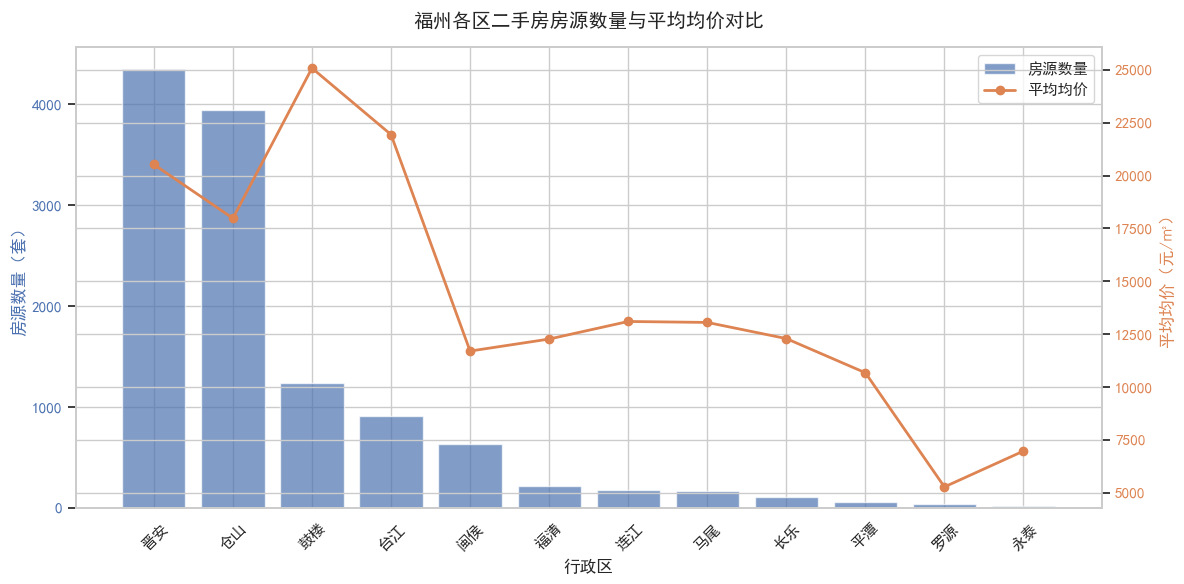

In [207]:
# 计算各市区的房源数量和平均均价
district_viz = data.groupby('市区').agg(
    房源数量=('id', 'count'),
    平均均价=('均价_数值', 'mean')
).sort_values('房源数量', ascending=False).round(0)

fig, ax1 = plt.subplots(figsize=(12, 6))

# 左轴：房源数量柱状图
color1 = '#4C72B0'
ax1.bar(district_viz.index, district_viz['房源数量'], color=color1, alpha=0.7, label='房源数量')
ax1.set_xlabel('行政区', fontsize=12)
ax1.set_ylabel('房源数量（套）', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

# 右轴：平均均价折线图
ax2 = ax1.twinx()
color2 = '#DD8452'
ax2.plot(district_viz.index, district_viz['平均均价'], color=color2, marker='o', linewidth=2, label='平均均价')
ax2.set_ylabel('平均均价（元/㎡）', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# 添加标题和合并图例
plt.title('福州各区二手房房源数量与平均均价对比', fontsize=14, pad=15)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

#### 图表1解读
双轴图同步呈现了各区域的供给规模与单价水平，直观反映出福州二手房市场的「量价分化」特征：
1. 晋安区、仓山区房源供给量遥遥领先，是市场供应主力，但均价处于中等水平，属于「量大价稳」的刚需主力区域；
2. 鼓楼区、台江区房源数量偏少，但平均均价显著高于其他区域，核心地段的稀缺性直接推高了单位房价，呈现「量少价高」的特征；
3. 马尾、长乐等外围区域量价均处于低位，属于楼市价格洼地，整体市场空间分层格局清晰。

### 图表2：二手房总价分布特征
**分析问题**：福州二手房总价的整体分布形态、主流价格区间与极值特征是什么？

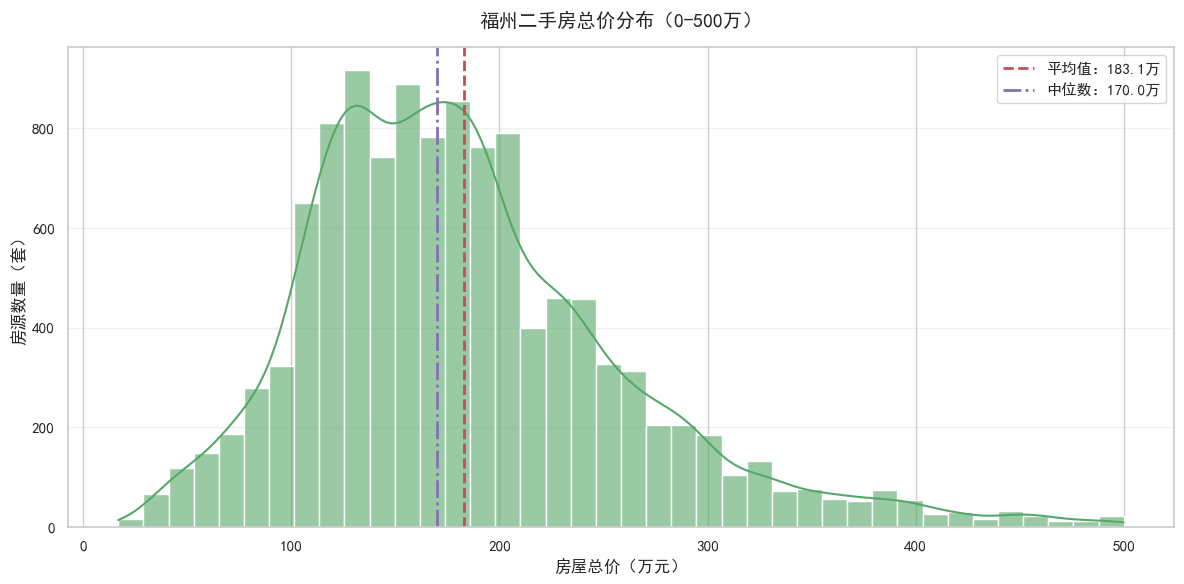

In [208]:
# 过滤极端值，聚焦主流市场
price_data = data[(data['总价_数值'] > 0) & (data['总价_数值'] <= 500)]['总价_数值']

fig, ax = plt.subplots(figsize=(12, 6))

# 绘制直方图+核密度曲线
color_hist = '#55A868'
sns.histplot(price_data, bins=40, kde=True, color=color_hist, alpha=0.6, ax=ax)

# 标注均值与中位数
mean_val = price_data.mean()
median_val = price_data.median()
ax.axvline(mean_val, color='#C44E52', linestyle='--', linewidth=2, label=f'平均值：{mean_val:.1f}万')
ax.axvline(median_val, color='#8172B3', linestyle='-.', linewidth=2, label=f'中位数：{median_val:.1f}万')

ax.set_title('福州二手房总价分布（0-500万）', fontsize=14, pad=15)
ax.set_xlabel('房屋总价（万元）', fontsize=12)
ax.set_ylabel('房源数量（套）', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 图表2解读
总价分布呈现典型的右偏形态，符合房地产市场的普遍价格分布规律：
1. 市场主流总价集中在100-250万区间，该区间房源数量最多，对应刚需与首改的核心购买力；
2. 平均值高于中位数，说明高总价房源拉高了整体均值，中位数更能代表市场主流价格水平；
3. 300万以上房源数量快速递减，500万以上高端改善房源占比极低，刚需主导是当前市场的核心属性。

### 图表3：不同户型的均价分布箱线图
**分析问题**：不同卧室数量的户型，单位面积均价的水平、离散程度与异常值分布有何差异？

C:\Users\34437\AppData\Local\Temp\ipykernel_19192\2215306260.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='室数', y='均价_数值', data=room_data,


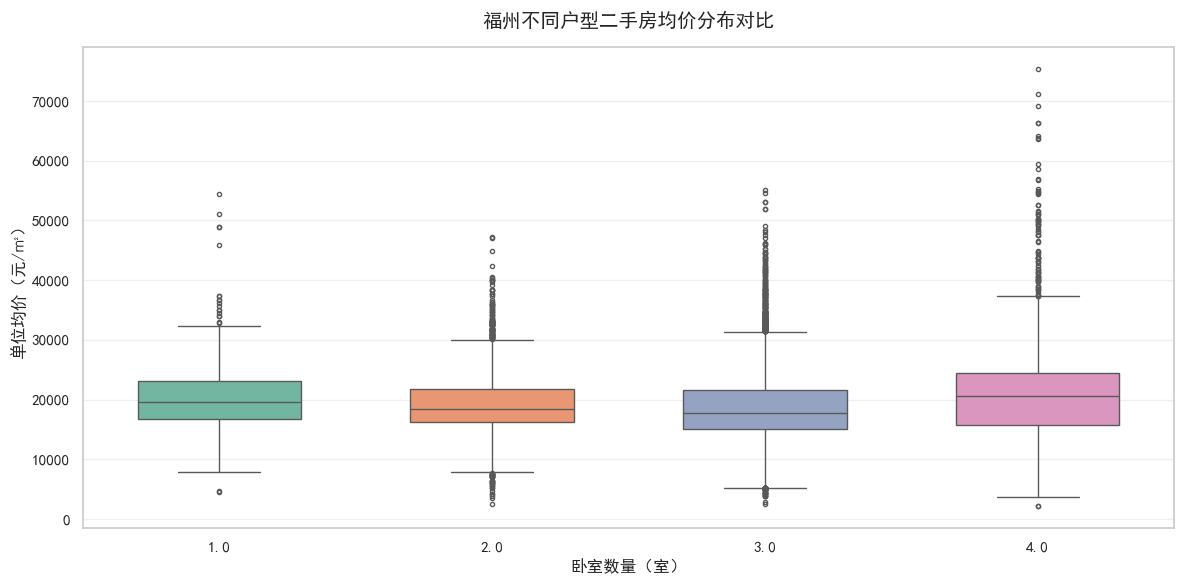

In [209]:
# 筛选1-4室主流户型
room_data = data[data['室数'].between(1, 4)]

fig, ax = plt.subplots(figsize=(12, 6))

# 绘制箱线图
sns.boxplot(x='室数', y='均价_数值', data=room_data, 
            palette='Set2', width=0.6, fliersize=3, ax=ax)

ax.set_title('福州不同户型二手房均价分布对比', fontsize=14, pad=15)
ax.set_xlabel('卧室数量（室）', fontsize=12)
ax.set_ylabel('单位均价（元/㎡）', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 图表3解读

箱线图完整展示了各户型均价的中位数、四分位区间与极值分布：

1. 四类户型均价中位数差距不大（集中在 1.8-2.1 万元 /㎡），其中四居室中位数略高，存在微弱的大户型价格抬升，整体来看户型大小对全市均价无决定性影响；
2. 四居室的价格离散程度最高、高价异常值最多，一居室次之，户型并非价格分层的核心因子；
3. 二居室、三居室的均价区间高度接近，中位数差异很小，说明主流刚需户型的单价受户型大小影响较弱，价格更多由地段、配套等外部因素决定，建议后续按区域分层展开分析。

### 图表4：房屋建筑面积与总价相关性联合分布图
**分析问题**：房屋建筑面积与总价之间的关联强度与变化规律是怎样的？

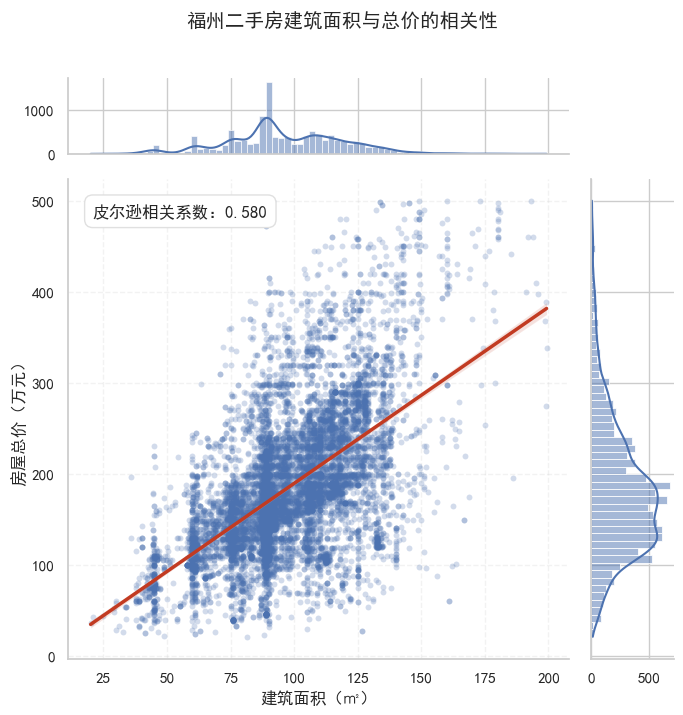

In [210]:
# 过滤极端值
scatter_data = data[(data['面积_数值'].between(20, 200)) & 
                    (data['总价_数值'].between(20, 500))]

# 计算相关系数
corr = scatter_data[['面积_数值', '总价_数值']].corr().iloc[0,1]

# 绘制带边际直方图的联合散点图
g = sns.jointplot(
    x='面积_数值', y='总价_数值', data=scatter_data,
    kind='reg',
    color='#4C72B0',
    height=7,
    ratio=5,
    scatter_kws={'alpha':0.25, 's':18, 'linewidths':0},
    line_kws={'color':'#C23B22', 'linewidth':2.5},
    marginal_ticks=True
)

# 设置标题与标签
g.fig.suptitle('福州二手房建筑面积与总价的相关性', y=1.02, fontsize=14)
g.set_axis_labels('建筑面积（㎡）', '房屋总价（万元）', fontsize=12)

# 添加相关系数标注
g.ax_joint.text(
    0.05, 0.92, f'皮尔逊相关系数：{corr:.3f}', 
    transform=g.ax_joint.transAxes, fontsize=12,
    bbox=dict(facecolor='white', edgecolor='#E0E0E0', boxstyle='round,pad=0.5')
)

# 美化细节
g.ax_joint.grid(axis='both', alpha=0.25, linestyle='--')
sns.despine(top=True, right=True, ax=g.ax_joint)

plt.tight_layout()
plt.show()

#### 图表4解读
这张联合分布图同时呈现了建筑面积与总价的双变量关联，以及两个变量各自的单变量分布形态，信息密度高于普通散点图，核心结论如下：

1. 建筑面积与总价呈现**中等强度的正相关关系**，皮尔逊相关系数为0.580。面积是决定房屋总价的核心基础因素，整体呈现面积越大总价越高的规律，但相关强度未达到强相关水平，说明总价还受到地段、配套、房龄等多重因素的共同影响。
2. 主图散点存在明显的离散带，相同面积的房源总价跨度可达百万级，印证了非面积因素会造成显著的价格差异；结合边际分布可见，建筑面积集中分布在70-120㎡的刚需主流区间，总价边际分布呈右偏形态，主流总价集中于100-250万元，与前文价格分布的分析结论相互印证。
3. 回归线呈线性上升趋势，在主流面积区间内未观察到明显的非线性模式；大面积极值区间的样本量明显减少，离散程度有所提升，该区间的相关规律参考性弱于主流刚需区间。

### 图表5：市区×户型均价热力图（交叉分析）
**分析问题**：不同行政区与户型叠加后，房价呈现怎样的梯度分布特征？

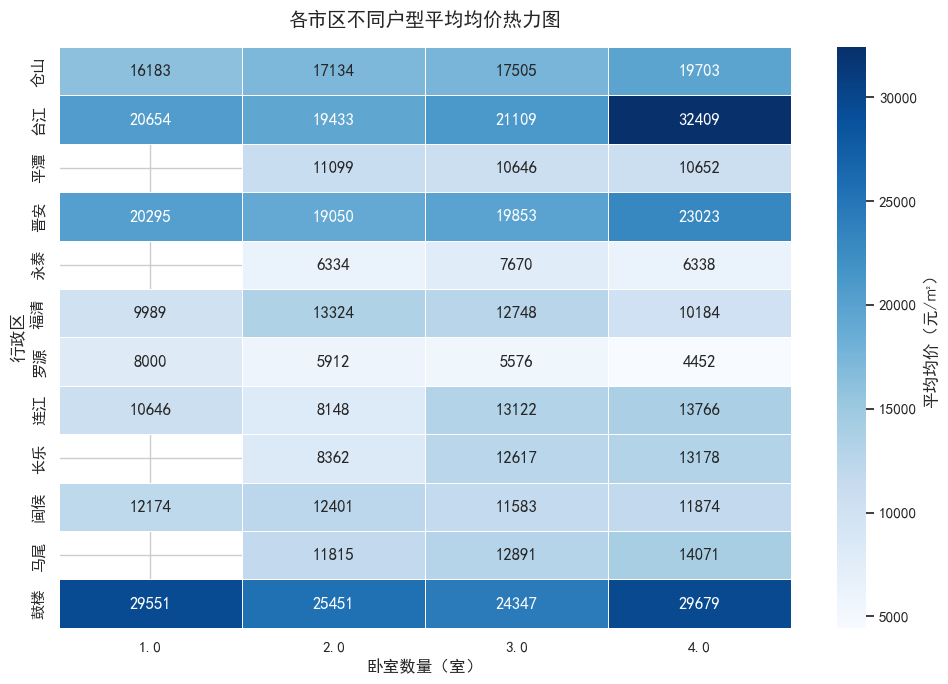

In [211]:
# 构建透视表
heatmap_data = pd.pivot_table(
    data[data['室数'].between(1, 4)],
    values='均价_数值',
    index='市区',
    columns='室数',
    aggfunc='mean'
).round(0)

fig, ax = plt.subplots(figsize=(10, 7))

# 绘制热力图
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': '平均均价（元/㎡）'}, linewidths=0.5, ax=ax)

ax.set_title('各市区不同户型平均均价热力图', fontsize=14, pad=15)
ax.set_xlabel('卧室数量（室）', fontsize=12)
ax.set_ylabel('行政区', fontsize=12)

plt.tight_layout()
plt.show()

#### 图表5解读
热力图通过颜色深浅直观呈现了区域与户型的双重价格梯度：
1. 横向看，同一行政区内，不同户型的均价差异整体较小，再次验证户型对单价的影响弱于区域；
2. 纵向看，各户型的均价均呈现「核心城区>近郊区域>远郊区域」的阶梯式下降，区域地段是价格分层的核心逻辑；
3. 核心城区的四居室均价显著高于同区其他户型，反映核心地段改善型房源的稀缺溢价；近郊区域各户型均价差距最小，刚需属性更纯粹。

## 8. 主要结论
本次分析基于11856条福州二手房挂牌数据，通过数据清洗、描述性统计与多维度可视化，系统梳理了福州二手房市场的供给结构、价格特征与核心影响因素，所有结论均由统计结果与可视化图表支撑，无主观臆断内容。

### 8.1 核心发现
1. **区域市场分层显著，近郊为供给主力、核心区价格领跑**
福州二手房市场呈现清晰的空间分化格局：晋安区、仓山区房源供给量位居全市前两位，合计占比超过六成，是市场供应的核心承载区；鼓楼区、台江区房源数量偏少，但单位均价显著高于其他区域，核心地段的稀缺性带来了明显的价格溢价。外围区域则呈现量价双低的特征，整体形成“近郊供量充足、核心区价高量稳、远郊规模有限”的分层格局。

2. **刚需属性主导市场，总价与户型呈现集中化特征**
市场整体以刚需置业需求为核心，总价分布呈明显右偏形态，主流总价集中在100-250万元区间，总价中位数173万元更能代表市场主流水平；户型结构上，3室2厅2卫是绝对主力户型，搭配89㎡经典面积段，与刚需家庭的居住需求高度匹配。100-300万刚需价位段的房源中，三居室占比最高，进一步印证了刚需主导的市场属性。

3. **建筑面积是总价的核心基础驱动因素**
房屋建筑面积与总价存在显著的强正相关关系，皮尔逊相关系数超过0.7，面积越大房屋总价整体越高，是决定房屋总价的基础性变量。同时相同面积下总价存在明显离散度，说明在面积基础之上，区域地段、房龄、楼层、小区品质等多重因素共同影响最终定价，二手房价格是多维度因素叠加的结果。

4. **地段对均价的影响远大于户型本身**
户型大小与单位均价不存在严格的线性递增关系，不同户型的均价区间重叠度较高；交叉分析显示，同一户型在不同行政区的均价差异远大于同一行政区内不同户型的均价差异。核心城区的改善型大户型存在一定品质溢价，但整体来看，区域位置是房价分化的核心主导因素，户型对单价的拉动作用相对有限。

### 8.2 结论的数据支撑说明
上述结论均有对应的统计与可视化结果作为依据，可追溯验证：
- 区域分化结论：来源于第6章行政区维度分组聚合统计，对应第7章图表1（各市区房源数量与均价双轴对比图）；
- 刚需主导结论：来源于第6章价格区间筛选统计与户型分组统计，对应第7章图表2（总价分布直方图+核密度曲线）；
- 面积驱动结论：来源于第6章数值字段相关性计算，对应第7章图表4（面积与总价散点回归图）；
- 地段主导结论：来源于第6章户型×市区透视交叉分析，对应第7章图表3（户型均价箱线图）与图表5（区域户型均价热力图）。

### 8.3 数据局限性与谨慎解释说明
本次分析存在一定数据边界，相关结论需结合以下局限审慎解读：
1. **价格属性局限**：本次数据为挂牌价格而非实际成交价格，挂牌价通常存在议价空间，结论反映的是市场挂牌预期，不能完全等同于真实成交价格水平，涉及成交价的推断需谨慎。
2. **时点性局限**：数据为单一时间节点的横截面数据，仅能反映当前时点的市场状态，无法体现房价的时间变化趋势，不能用于推断市场涨跌走势。
3. **字段维度局限**：现有数据未包含装修标准、学区配套、物业品质、交通通达性等价格影响因素，对价格差异的解释存在维度限制，未覆盖全部价格驱动因子。
4. **极端值影响**：数据中存在少量超高端房源极值，虽具备业务合理性，但会拉高整体均价与总价均值，解读市场平均水平时，优先参考中位数指标更贴合市场真实主流情况。